[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/natrask/ENM5320-2026/blob/main/NewMaterial/whitney_tut/DataDriven_Whitney_Forms.ipynb)

# Data-Driven Whitney Forms: 1D Tutorial

This notebook builds a **data-driven inverse problem** on a coarsened finite element representation using **Whitney forms**.  
We will:

1. Construct a standard 1D **piecewise-linear (P1) finite element** mesh on $[0,1]$.
2. Build a **trainable convex combination tensor** $W$ that coarsens the fine-scale hat functions into a small number of partition-of-unity (POU) basis functions.
3. Derive **Whitney 0-forms** and **1-forms** from $W$, preserving the de Rham structure $\text{grad}(W^0) \subseteq W^1$.
4. Pose the 1D steady **advection–diffusion equation** in first-order (flux) form and generate exact-solution training data for a user-specified **Péclet number**.
5. Learn, from data, a **constitutive model** $\hat{F}(\hat{u})$ that combines a trainable diffusivity $\mu$ with a small neural-network nonlinearity $N(\hat{u})$.

> **Note on ill-posedness.**  The decomposition into $\mu$ (linear diffusion) and $N(\hat{u})$ (nonlinear correction) is **not unique**: diffusion can be partially absorbed by the NN, and vice versa.  The learned $\mu$ should therefore not be expected to recover the true Péclet number exactly.

### Prerequisites
* Familiarity with 1D finite elements (hat functions, mass/stiffness matrices, Gauss quadrature) — see the companion `FEMconvergence_demo.ipynb`.
* Basic PyTorch tensor operations and `torch.autograd`.

## Step 0 — Imports and Setup

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

dtype = torch.float64          # double precision throughout
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Step 1 — Build the 1D Finite Element Mesh

We place $N$ uniformly spaced nodes on $[0,1]$ with element size $h = 1/(N-1)$.  
A finer grid `finepoints` is used only for plotting.

In [2]:
# ========== USER-CONFIGURABLE PARAMETERS ==========
meshsize = 32          # number of fine-scale FEM nodes
Npou     = 4           # number of coarse POU functions (Whitney 0-forms)
Nbatch   = 2           # number of training samples per optimisation step
Pe_target = 10.0       # target Péclet number  (Pe = 1/(2*eps))
# ===================================================

h = 1.0 / (meshsize - 1)
points = torch.linspace(0, 1, meshsize, dtype=dtype)
finepoints = torch.linspace(0, 1, 20 * meshsize, dtype=dtype)

N1forms = Npou * (Npou - 1) // 2   # number of Whitney 1-form basis functions
eps_true = 1.0 / (2.0 * Pe_target)  # true diffusivity from Péclet number

print(f'meshsize = {meshsize},  h = {h:.4f}')
print(f'Npou = {Npou},  N1forms = {N1forms}')
print(f'Pe = {Pe_target},  eps = {eps_true:.6f}')

meshsize = 32,  h = 0.0323
Npou = 4,  N1forms = 6
Pe = 10.0,  eps = 0.050000


## Step 2 — Hat Basis Functions $\phi_i$ and Their Gradients

The P1 hat function centred on node $x_i$ is

$$\phi_i(x) = \max\!\bigl(0,\; 1 - |x - x_i|/h\bigr)$$

Key properties:
1. **Compact support** — $\phi_i$ is non-zero only on $[x_{i-1}, x_{i+1}]$.
2. **Partition of unity** — $\sum_i \phi_i(x) = 1$ for all $x \in [0,1]$.
3. **Interpolation** — $\phi_i(x_j) = \delta_{ij}$.
4. **Piecewise-constant gradient** — $\phi_i'(x) = \pm 1/h$ inside the support, $0$ outside.

We evaluate all $N$ basis functions simultaneously at a batch of query points using broadcasting.

In [3]:
def evalPhi_i(x):
    """Evaluate all N hat functions at query points x.  Returns shape (N, len(x))."""
    return torch.relu(1.0 - torch.abs(x.unsqueeze(0) - points.unsqueeze(1)) / h)

def evalGradPhi_i(x):
    """Gradient of hat functions.  Returns shape (N, len(x))."""
    suppPhi = (evalPhi_i(x) > 0).double()
    signPlus  = (points.unsqueeze(1) >  x.unsqueeze(0)).double()
    signNeg   = (points.unsqueeze(1) <= x.unsqueeze(0)).double()
    return suppPhi * (signNeg - signPlus) / h

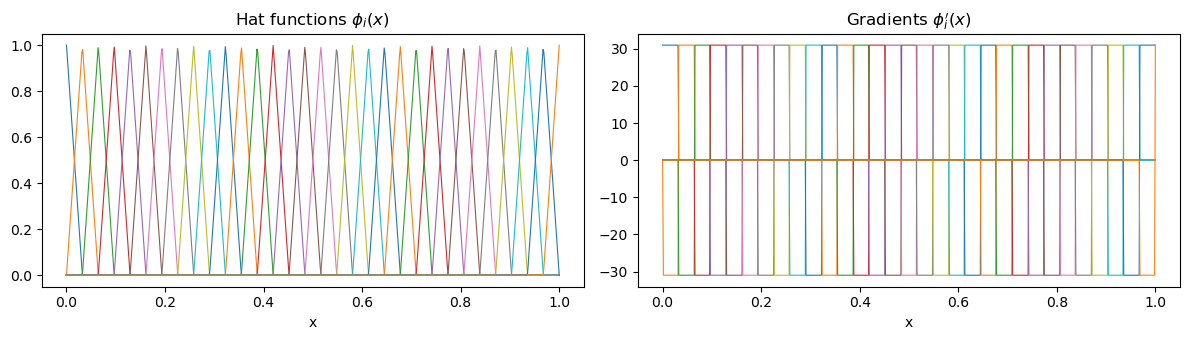

In [4]:
# Visualise a few hat functions and their derivatives
phi_fine = evalPhi_i(finepoints)
gphi_fine = evalGradPhi_i(finepoints)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(finepoints.numpy(), phi_fine.numpy().T, lw=0.8)
axes[0].set_title(r'Hat functions $\phi_i(x)$')
axes[1].plot(finepoints.numpy(), gphi_fine.numpy().T, lw=0.8)
axes[1].set_title(r'Gradients $\phi_i^\prime(x)$')
for ax in axes:
    ax.set_xlabel('x')
plt.tight_layout()
plt.show()

## Step 3 — Gauss–Legendre Quadrature

To compute integrals element-by-element we use $n_q$-point Gauss–Legendre quadrature on each of the $N-1$ elements.  The reference rule on $[-1,1]$ is mapped to each element $[x_k, x_{k+1}]$:

$$x_{q} = x_k + \tfrac{h}{2}(1 + \xi_q), \qquad w_{q} = \tfrac{h}{2}\,\hat{w}_q$$

where $\xi_q, \hat{w}_q$ are the reference points and weights.

In [5]:
Nquad = 4  # quadrature points per element
ref_pts, ref_wts = np.polynomial.legendre.leggauss(Nquad)
ref_pts = torch.tensor(ref_pts, dtype=dtype)
ref_wts = torch.tensor(ref_wts, dtype=dtype)

# Map to physical elements
xq  = (points[:-1].unsqueeze(-1) + 0.5 * h * (1.0 + ref_pts.unsqueeze(0))).flatten()
wq  = (ref_wts.unsqueeze(0).expand(meshsize - 1, -1) * (h / 2.0)).flatten()
idx = torch.argsort(xq)
xq  = xq[idx]
wq  = wq[idx]

# Pre-evaluate fine-scale basis functions at quadrature points
nodal_basisEval     = evalPhi_i(xq)      # (meshsize, Nq)
nodal_gradbasisEval = evalGradPhi_i(xq)   # (meshsize, Nq)

print(f'Total quadrature points: {len(xq)}')

Total quadrature points: 124


## Step 4 — The Convex Combination Tensor $W$ and the Partition of Unity

### Idea

We want to **coarsen** the $N$ fine-scale hat functions $\{\phi_j\}$ down to $N_{\text{pou}}$ "super-basis" functions $\{\psi_i\}$ while **preserving the partition of unity**.  The key device is a *convex combination tensor* $W \in \mathbb{R}^{N_{\text{pou}} \times N}$.

### Construction

We define the coarse Whitney 0-form basis functions as

$$\psi_i(x) = \sum_{j=1}^{N} W_{ij}\,\phi_j(x), \qquad i = 1,\dots,N_{\text{pou}}$$

For the $\psi_i$ to form a **partition of unity** we need

$$\sum_{i=1}^{N_{\text{pou}}} \psi_i(x) = 1 \quad \forall x.$$

Substituting the definition:

$$\sum_i \psi_i(x) = \sum_i \sum_j W_{ij}\,\phi_j(x) = \sum_j \Bigl(\underbrace{\sum_i W_{ij}}_{=\,1}\Bigr) \phi_j(x) = \sum_j \phi_j(x) = 1.$$

So the partition-of-unity condition is satisfied whenever **each column of $W$ sums to 1** with non-negative entries.  We enforce this by applying a **column-wise softmax** to a matrix of unconstrained logits $\Theta$:

$$W_{ij} = \frac{e^{\Theta_{ij}}}{\sum_k e^{\Theta_{kj}}} \;\ge 0, \qquad \sum_i W_{ij} = 1.$$

### Boundary Handling

For Dirichlet boundary conditions we pin:
* $\psi_1(x)$ to equal $\phi_1(x)$ alone  → $W_{1,1}=1$, all other entries in column 1 are 0.
* $\psi_{N_{\text{pou}}}(x)$ to equal $\phi_N(x)$ alone → $W_{N_{\text{pou}},N}=1$, all other entries in column $N$ are 0.

This lets us lift Dirichlet values directly through the coarse basis.

### Why $W$ is Trainable

$W$ is initialised randomly and **optimised jointly** with the constitutive model.  During training the optimiser adjusts $\Theta$ (and hence $W$) so that the coarse POU functions $\psi_i$ cluster fine-scale nodes in a way that best captures the physics of the problem.

In [6]:
# Trainable logits for W (interior nodes only)
Wijlogit = nn.Parameter(torch.randn(Npou - 2, meshsize - 2, dtype=dtype))

def build_Wij():
    """Construct W with softmax interior + pinned Dirichlet boundaries."""
    interior = torch.softmax(Wijlogit, dim=0)                          # (Npou-2, meshsize-2)
    # Row for left BC:  [1, 0, ..., 0]
    row_left  = torch.zeros(1, meshsize, dtype=dtype)
    row_left[0, 0] = 1.0
    # Row for right BC: [0, ..., 0, 1]
    row_right = torch.zeros(1, meshsize, dtype=dtype)
    row_right[0, -1] = 1.0
    # Interior rows: zero-pad first and last columns
    row_mid = torch.cat([
        torch.zeros(Npou - 2, 1, dtype=dtype),
        interior,
        torch.zeros(Npou - 2, 1, dtype=dtype)
    ], dim=1)
    return torch.cat([row_left, row_mid, row_right], dim=0)            # (Npou, meshsize)

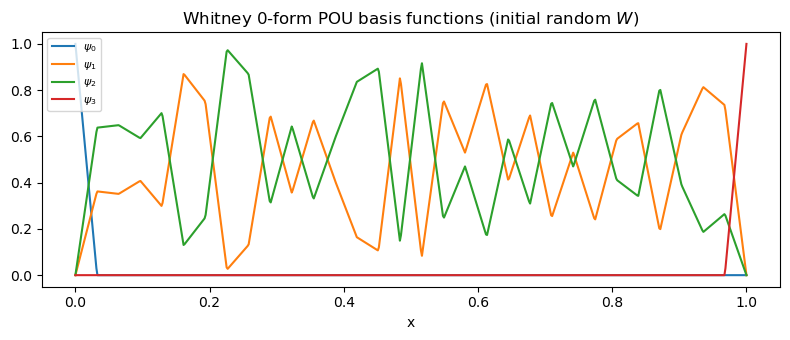

Partition of unity max error: 2.66e-15


In [7]:
# Visualise the initial POU basis functions
with torch.no_grad():
    Wij = build_Wij()
    psi0_fine = Wij @ evalPhi_i(finepoints)   # (Npou, len(finepoints))

fig, ax = plt.subplots(figsize=(8, 3.5))
for i in range(Npou):
    ax.plot(finepoints.numpy(), psi0_fine[i].numpy(), label=rf'$\psi_{{{i}}}$')
ax.set_title('Whitney 0-form POU basis functions (initial random $W$)')
ax.set_xlabel('x');  ax.legend(fontsize=8)
plt.tight_layout();  plt.show()

# Verify partition of unity
pou_sum = psi0_fine.sum(dim=0)
print(f'Partition of unity max error: {(pou_sum - 1.0).abs().max().item():.2e}')

## Step 5 — Whitney 1-Forms and the Coboundary Operator $\delta_0$

### Whitney 1-Forms

Given the 0-form basis $\{\psi_i\}$ we construct **edge-based 1-form** basis functions:

$$\psi_{ij}(x) = \psi_j(x)\,\psi_i'(x) \;-\; \psi_i(x)\,\psi_j'(x), \qquad j > i.$$

Key properties:
* **Anti-symmetry**: $\psi_{ij} = -\psi_{ji}$, so we only store the upper triangle ($j>i$), giving $N_{\text{1forms}} = N_{\text{pou}}(N_{\text{pou}}-1)/2$ independent 1-forms.
* **De Rham compatibility**: $\nabla(W^0) \subseteq W^1$ — every gradient of a Whitney 0-form is a linear combination of Whitney 1-forms.  This is the discrete analogue of $\text{curl}\circ\text{grad} = 0$.
* **Physical interpretation**: in 1D the 1-forms represent *fluxes between coarse nodes*.  The anti-symmetry ensures that flux from node $i$ to node $j$ is exactly the negative of the flux from $j$ to $i$ — guaranteeing **local conservation**.

### Coboundary Operator $\delta_0$

The combinatorial gradient (coboundary) matrix $\delta_0 \in \mathbb{R}^{N_{\text{1forms}} \times N_{\text{pou}}}$ encodes the directed graph on the $N_{\text{pou}}$ coarse nodes.  For edge $e = (i,j)$ with $j > i$:

$$[\delta_0]_{e,i} = -1, \qquad [\delta_0]_{e,j} = +1$$

This matrix maps 0-form coefficients to 1-form coefficients: $\delta_0 \hat{u}$ gives the "discrete gradient" on each edge.

In [8]:
# Build the coboundary operator delta0
delta0 = torch.zeros(N1forms, Npou, dtype=dtype)
cnt = 0
for i in range(Npou):
    for j in range(i + 1, Npou):
        delta0[cnt, j] =  1.0
        delta0[cnt, i] = -1.0
        cnt += 1

print('delta0 shape:', delta0.shape)
print(delta0)

delta0 shape: torch.Size([6, 4])
tensor([[-1.,  1.,  0.,  0.],
        [-1.,  0.,  1.,  0.],
        [-1.,  0.,  0.,  1.],
        [ 0., -1.,  1.,  0.],
        [ 0., -1.,  0.,  1.],
        [ 0.,  0., -1.,  1.]], dtype=torch.float64)


In [9]:
def eval_psi0(Wij, xeval_basis):
    """Whitney 0-forms at precomputed basis evaluations.  (Npou, Nq)"""
    return Wij @ xeval_basis

def eval_psi1(Wij, xeval_basis, xeval_gradbasis):
    """Whitney 1-forms at precomputed evaluations.  (N1forms, Nq)"""
    psi0 = Wij @ xeval_basis          # (Npou, Nq)
    gpsi0 = Wij @ xeval_gradbasis     # (Npou, Nq)
    # psi_ij = psi_j * gpsi_i  -  psi_i * gpsi_j   for j > i
    full = psi0.unsqueeze(0) * gpsi0.unsqueeze(1) - psi0.unsqueeze(1) * gpsi0.unsqueeze(0)  # (Npou,Npou,Nq)
    # Extract upper triangle using the same (i,j) ordering as delta0
    mask = torch.triu(torch.ones(Npou, Npou, dtype=torch.bool), diagonal=1)
    return full[mask]  # (N1forms, Nq)

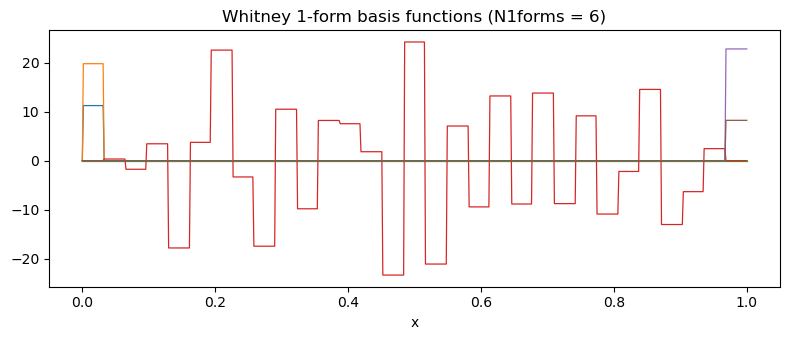

In [10]:
# Visualise 1-forms (initial random W)
with torch.no_grad():
    Wij = build_Wij()
    phi_fine_basis = evalPhi_i(finepoints)
    gphi_fine_basis = evalGradPhi_i(finepoints)
    psi1_fine = eval_psi1(Wij, phi_fine_basis, gphi_fine_basis)

fig, ax = plt.subplots(figsize=(8, 3.5))
for e in range(N1forms):
    ax.plot(finepoints.numpy(), psi1_fine[e].numpy(), lw=0.9)
ax.set_title(f'Whitney 1-form basis functions (N1forms = {N1forms})')
ax.set_xlabel('x')
plt.tight_layout();  plt.show()

## Step 6 — Mass Matrices and the Divergence Operator

We assemble:

| Matrix | Definition | Shape |
|--------|-----------|-------|
| $M^0_{ij}$ | $\displaystyle\int_0^1 \psi_i\,\psi_j\,dx$ | $N_{\text{pou}} \times N_{\text{pou}}$ |
| $M^1_{ef}$ | $\displaystyle\int_0^1 \psi_e\,\psi_f\,dx$ | $N_{\text{1forms}} \times N_{\text{1forms}}$ |
| $D_{ei}$ | $\displaystyle\int_0^1 \psi_e\,\psi_i'\,dx$ | $N_{\text{1forms}} \times N_{\text{pou}}$ |

The **structure-preserving identity** $D = -\delta_0^T M^1$ must hold (up to numerical precision).  This is the discrete analogue of integration-by-parts and guarantees that the Whitney discretisation respects the de Rham complex.

In [11]:
def assemble_matrices(Wij):
    """Assemble M0, M1, divMat for a given W."""
    psi0_q = eval_psi0(Wij, nodal_basisEval)           # (Npou, Nq)
    gpsi0_q = eval_psi0(Wij, nodal_gradbasisEval)       # (Npou, Nq)  (= grad of 0-forms)
    psi1_q = eval_psi1(Wij, nodal_basisEval, nodal_gradbasisEval)  # (N1forms, Nq)

    # 0-form mass matrix
    M0 = torch.einsum('iq,jq,q->ij', psi0_q, psi0_q, wq)
    # 1-form mass matrix
    M1 = torch.einsum('eq,fq,q->ef', psi1_q, psi1_q, wq)
    # Mixed bilinear form (psi1, grad psi0)
    divMat = torch.einsum('eq,jq,q->ej', psi1_q, gpsi0_q, wq)
    return M0, M1, divMat, psi0_q, psi1_q

In [12]:
# Verify de Rham identity:  divMat  ≈  -delta0^T @ M1
with torch.no_grad():
    Wij = build_Wij()
    M0, M1, divMat, _, _ = assemble_matrices(Wij)
    divMat_check = -delta0.T @ M1
    err = (divMat.T - divMat_check).norm() / divMat.norm()
    print(f'de Rham identity relative error: {err.item():.2e}')

de Rham identity relative error: 2.26e-16


## Step 7 — The 1D Advection–Diffusion Equation

We consider the steady 1D advection–diffusion problem

$$-\varepsilon\,u''(x) + u'(x) = 0, \qquad x \in (0,1)$$

with Dirichlet boundary conditions $u(0) = 0$, $u(1) = 1$.

### Exact Solution

$$u(x) = \frac{1 - e^{x/\varepsilon}}{1 - e^{1/\varepsilon}}$$

### Péclet Number

The (global) Péclet number measures the ratio of advection to diffusion:

$$\text{Pe} = \frac{a\,L}{2\varepsilon} = \frac{1}{2\varepsilon}$$

(with advection velocity $a=1$ and domain length $L=1$).  

* **Pe $\ll 1$**: diffusion-dominated — smooth solutions.  
* **Pe $\gg 1$**: advection-dominated — sharp boundary layer near $x=1$.

### First-Order (Flux) Form

Define the flux $F = u - \varepsilon\,u'$.  Then the PDE becomes $F' = 0$ (constant flux), which is the form we discretise with Whitney forms.

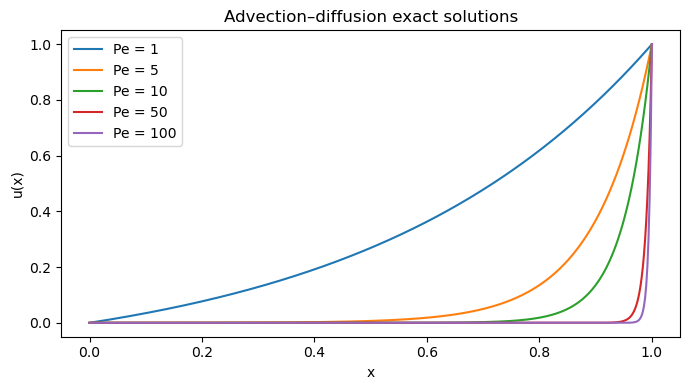

In [13]:
def advdiff_exact(x, eps):
    """Exact solution and its derivative for the 1D advection-diffusion eqn."""
    # u(x) = (1 - exp(x/eps)) / (1 - exp(1/eps))
    exp_x = torch.exp(x / eps)
    exp_1 = torch.exp(torch.tensor(1.0 / eps, dtype=dtype))
    u    = (1.0 - exp_x) / (1.0 - exp_1)
    dudx = -(1.0 / eps) * exp_x / (1.0 - exp_1)
    return u, dudx

# Plot solutions for several Péclet numbers
xplot = torch.linspace(0, 1, 500, dtype=dtype)
fig, ax = plt.subplots(figsize=(7, 4))
for Pe in [1, 5, 10, 50, 100]:
    eps_i = 1.0 / (2.0 * Pe)
    u_i, _ = advdiff_exact(xplot, eps_i)
    ax.plot(xplot.numpy(), u_i.numpy(), label=f'Pe = {Pe}')
ax.set_xlabel('x');  ax.set_ylabel('u(x)')
ax.set_title('Advection–diffusion exact solutions')
ax.legend();  plt.tight_layout();  plt.show()

## Step 8 — Generate Training Data

We evaluate the exact solution at the quadrature points for several scales of the solution (mimicking multiple experiments).  The training data consists of:

* $u_\text{data}$ — solution values at quadrature points

Dirichlet boundary conditions ($u(0) = 0$, $u(1) = \text{scale}$) are enforced directly in the Newton solver by row elimination.

In [14]:
# Generate data at target Peclet number with multiple solution scalings
uscale = torch.linspace(1.0, 3.0, Nbatch, dtype=dtype)

u_exact_q, dudx_exact_q = advdiff_exact(xq, eps_true)
# Stack scaled copies:  udata (Nbatch, Nq)  — each row is a different "experiment"
udata   = u_exact_q.unsqueeze(0) * uscale.unsqueeze(1)
dxudata = dudx_exact_q.unsqueeze(0) * uscale.unsqueeze(1)
F_data  = udata - eps_true * dxudata   # (Nbatch, Nq)

print(f'udata shape:  {udata.shape}')
print(f'F_data shape: {F_data.shape}')

udata shape:  torch.Size([2, 124])
F_data shape: torch.Size([2, 124])


In [15]:
def compute_boundary_forcing(Wij, F_data):
    """Compute the boundary flux contribution to the RHS.
    FBC_di = psi_i(1)*F(1) - psi_i(0)*F(0)  for each batch sample d.
    """
    psi0_q = eval_psi0(Wij, nodal_basisEval)
    q_left  = psi0_q[:, 0]     # psi_i(x=0)  — shape (Npou,)
    q_right = psi0_q[:, -1]    # psi_i(x=1)  — shape (Npou,)
    F_left  = F_data[:, 0]     # (Nbatch,)
    F_right = F_data[:, -1]    # (Nbatch,)
    # FBC shape: (Nbatch, Npou)
    return torch.einsum('n,d->dn', q_right, F_right) - torch.einsum('n,d->dn', q_left, F_left)

## Step 9 — Neural Constitutive Model

We model the discrete 1-form flux coefficients as

$$\hat{F}_e = \mu\,[\delta_0\,\hat{u}]_e \;+\; N_\theta(\hat{u})_e$$

where

* $\mu = e^{\lambda}$ is a **trainable scalar** (the learned diffusivity, parameterised via log to keep it positive).  The term $\mu\,\delta_0\,\hat{u}$ is the **discrete gradient** of $\hat{u}$ — a *first-order* operator mapping 0-form coefficients to 1-form (edge) coefficients.
* $N_\theta: \mathbb{R}^{N_{\text{pou}}} \to \mathbb{R}^{N_{\text{1forms}}}$ is a small **MLP** that learns any flux contribution not captured by the linear gradient term.

### PDE Residual Structure

The Hodge Laplacian $S = \delta_0^T M^1 \delta_0$ weights the diffusive gradient with the 1-form inner product.  The NN correction enters as $\delta_0^T N_\theta(\hat{u})$ without $M^1$ (the NN can absorb any such weighting internally).  The residual is

$$R = \mu\,\underbrace{\delta_0^T M^1 \delta_0}_{S}\,\hat{u} \;+\; \delta_0^T N_\theta(\hat{u}) \;-\; \hat{f}$$

### Ill-Posedness of the Inverse Problem

The split between $\mu$ and $N_\theta$ is **not unique**.  Any portion of the diffusion can be absorbed into the NN, and conversely the NN can offload gradient-like behaviour onto $\mu$.  Consequently, there is no guarantee that $\mu$ will recover the true $\varepsilon$: some diffusion may be modelled by $N_\theta$, some advection may shift $\mu$.  The model only needs to reproduce the data, not decompose the flux in a physically meaningful way.

The NN output layer is initialised to **zero** so that at startup the system is purely diffusive ($\mu S$) — this ensures the Newton solver has a well-conditioned matrix at the first iteration.

In [24]:
DNN_width = 10

class FluxNN(nn.Module):
    """Small MLP for nonlinear flux correction."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(Npou, DNN_width),
            nn.Tanh(),
            nn.Linear(DNN_width, DNN_width),
            nn.Tanh(),
        )
        # Final layer initialised to zero so the model starts linear
        self.W_out = nn.Parameter(torch.zeros(N1forms, DNN_width, dtype=dtype))
        # Ensure all params are float64
        self.double()

    def forward(self, uhat):
        """uhat: (Nbatch, Npou) → N_u: (Nbatch, N1forms)"""
        h = self.net(uhat)                       # (Nbatch, DNN_width)
        return torch.einsum('ew,bw->be', self.W_out, h)  # (Nbatch, N1forms)

flux_nn = FluxNN()

# Trainable log-diffusivity
log_mu = nn.Parameter(torch.tensor(0.0, dtype=dtype))

## Step 10 — PDE Residual and Newton–Raphson Forward Solve

### Discrete PDE

The residual (see Step 9) is

$$R_k(\hat{u}) = \mu\,[S\,\hat{u}]_k + [\delta_0^T N(\hat{u})]_k - \hat{f}_k = 0$$

where $S = \delta_0^T M^1 \delta_0$ is the Hodge Laplacian.

### Dirichlet Boundary Conditions

Rather than computing boundary flux integrals, we enforce Dirichlet conditions by **row elimination**: zero out rows 0 and $N_{\text{pou}}-1$ of the system matrix, set the diagonal entry to 1, and set the corresponding RHS entry to the prescribed boundary value.

### Linearised System

Linearising around $\hat{u}^{(n)}$:

$$A = \mu\,S + \delta_0^T J_N(\hat{u}^{(n)})$$

$$b = \delta_0^T \bigl(J_N(\hat{u}^{(n)})\,\hat{u}^{(n)} - N(\hat{u}^{(n)})\bigr)$$

After applying Dirichlet rows, the Newton update is $\hat{u}^{(n+1)} = A^{-1} b$.

In [25]:
def compute_jacobian_nn(flux_nn, uhat):
    """Compute Jacobian of flux_nn w.r.t. uhat.  Returns (Nbatch, N1forms, Npou)."""
    uhat_var = uhat.detach().requires_grad_(True)
    N_u = flux_nn(uhat_var)  # (Nbatch, N1forms)
    JN = []
    for e in range(N1forms):
        grad_e = torch.autograd.grad(N_u[:, e].sum(), uhat_var, create_graph=True)[0]
        JN.append(grad_e)
    return N_u, torch.stack(JN, dim=1)  # N_u: (B,E), JN: (B,E,Npou)

def residual_fn(uhat, Wij, flux_nn):
    """PDE residual R = mu * S @ uhat + delta0^T @ N(uhat) - b,
    with Dirichlet rows zeroed out."""
    mu = torch.exp(log_mu)
    _, M1, _, _, _ = assemble_matrices(Wij)
    S = delta0.T @ M1 @ delta0   # (Npou, Npou)
    N_u = flux_nn(uhat)           # (B, N1forms)
    res = mu * (S @ uhat.T).T + torch.einsum('ne,be->bn', delta0.T, N_u)
    return res  # (B, Npou) — caller handles RHS and Dirichlet

def newton_solve(fhat, Wij, flux_nn, uhat_init, bc_left, bc_right, n_iter=10):
    """Full Newton–Raphson solve with Dirichlet BCs enforced by row elimination.
    bc_left, bc_right: (Nbatch,) boundary values for psi_0 and psi_{Npou-1}.
    Returns uhat (Nbatch, Npou)."""
    mu = torch.exp(log_mu)
    _, M1, _, _, _ = assemble_matrices(Wij)
    S = delta0.T @ M1 @ delta0   # (Npou, Npou)

    uhat = uhat_init.clone()
    for _ in range(n_iter):
        N_u, JN_u = compute_jacobian_nn(flux_nn, uhat)

        # System matrix  A = mu*S + delta0^T @ JN_u
        A = mu * S.unsqueeze(0) + torch.einsum('ne,bem->bnm', delta0.T, JN_u)  # (B,Npou,Npou)

        # RHS  b = fhat + delta0^T @ (JN_u @ uhat - N_u)
        b_nn = torch.einsum('ne,be->bn', delta0.T,
                            torch.einsum('bem,bm->be', JN_u, uhat) - N_u)
        b = fhat + b_nn  # (B, Npou)

        # Enforce Dirichlet BCs: zero out BC rows, set diagonal to 1, RHS to BC value
        A[:, 0, :]  = 0.0;  A[:, 0, 0]   = 1.0;  b[:, 0]  = bc_left
        A[:, -1, :] = 0.0;  A[:, -1, -1] = 1.0;  b[:, -1] = bc_right

        uhat = torch.linalg.solve(A, b)  # (B, Npou)

    return uhat

## Step 11 — Loss Function and Optimiser

### Loss

We use a simple $L^2$ fitting loss:

$$\mathcal{L} = \sum_d \|u_\text{eval}^{(d)} - u_\text{data}^{(d)}\|^2$$

### Optimisation Cycle

At each iteration:

1. **Forward solve** (Newton–Raphson): given current model parameters $(\mu, \theta, W)$, find $\hat{u}$ such that $R(\hat{u}) \approx 0$ with Dirichlet BCs enforced.
2. **Evaluate and compute loss**: project $\hat{u}$ onto quadrature points via the Whitney 0-forms and compare to data.
3. **Backpropagate**: `loss.backward()` differentiates through the final Newton step to update all trainable parameters.

In [ ]:
# Collect all trainable parameters
all_params = list(flux_nn.parameters()) + [log_mu, Wijlogit]
optimizer = optim.Adam(all_params, lr=1e-3)

Ntrainsteps = 1500
Nnewton     = 10     # Newton iterations per training step

## Step 12 — Training Loop

The training alternates between:
1. Rebuilding $W$ (softmax of current logits)
2. Running Newton–Raphson with Dirichlet BCs to solve for $\hat{u}$
3. Computing the fitting loss $\mathcal{L}$
4. Backpropagating through the Newton step and taking a gradient step

The NN output layer is initialised to zero, so at startup the system is purely diffusive ($\mu S$) — guaranteed to be solvable.  As training progresses, `N(u)` learns the advective contribution.

In [32]:
loss_history = []

# Dirichlet BC values for each batch sample: u(0) = 0, u(1) = scale
bc_left  = torch.zeros(Nbatch, dtype=dtype)
bc_right = uscale.clone()  # u(1) = scale_d

psi_hat_last = torch.zeros(Nbatch, Npou, dtype=dtype)

for it in range(1, Ntrainsteps + 1):
    optimizer.zero_grad()

    # 1. Build current W
    Wij = build_Wij()

    # 2. Boundary forcing (zero body force — advdiff has f=0)
    fhat = torch.zeros(Nbatch, Npou, dtype=dtype)

    # 3. Newton–Raphson forward solve (detach between iterations, keep graph on last)
    uhat = psi_hat_last.clone()
    for k in range(Nnewton):
        uhat = newton_solve(fhat, Wij, flux_nn, uhat.detach(), bc_left, bc_right, n_iter=1)

    # 4. Evaluate solution on nodes and compute fitting loss
    psi0_q = eval_psi0(Wij, nodal_basisEval)              # (Npou, Nq)
    u_eval = torch.einsum('iq,di->dq', psi0_q, uhat)      # (Nbatch, Nq)
    loss = ((u_eval - udata) ** 2).sum()

    loss.backward()
    optimizer.step()

    psi_hat_last = uhat.detach()
    loss_history.append(loss.item())

    if it % 500 == 0 or it == 1:
        mu_val = torch.exp(log_mu).item()
        print(f'iter {it:5d} | L_fit = {loss.item():.4e} | '
              f'mu = {mu_val:.6f} (eps_true = {eps_true:.6f})')

iter     1 | L_fit = 1.8849e+00 | mu = 0.633090 (eps_true = 0.050000)
iter   500 | L_fit = 7.4697e-02 | mu = 0.486870 (eps_true = 0.050000)
iter  1000 | L_fit = 1.6332e-02 | mu = 0.457607 (eps_true = 0.050000)
iter  1500 | L_fit = 1.6281e-02 | mu = 0.456857 (eps_true = 0.050000)
iter  2000 | L_fit = 1.6281e-02 | mu = 0.456855 (eps_true = 0.050000)
iter  2500 | L_fit = 1.6281e-02 | mu = 0.456855 (eps_true = 0.050000)
iter  3000 | L_fit = 1.6281e-02 | mu = 0.456855 (eps_true = 0.050000)
iter  3500 | L_fit = 1.6281e-02 | mu = 0.456855 (eps_true = 0.050000)
iter  4000 | L_fit = 1.6281e-02 | mu = 0.456855 (eps_true = 0.050000)
iter  4500 | L_fit = 1.6281e-02 | mu = 0.456855 (eps_true = 0.050000)
iter  5000 | L_fit = 1.6298e-02 | mu = 0.456862 (eps_true = 0.050000)


## Step 13 — Results and Visualisation

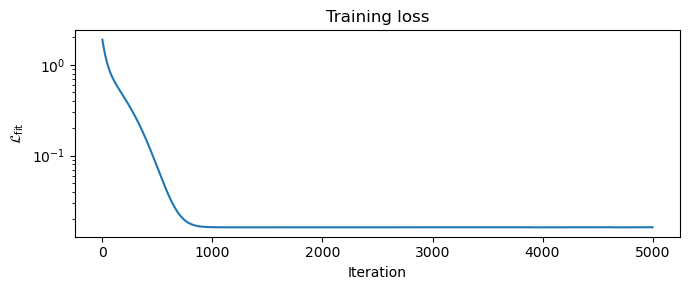

In [33]:
# Loss curve
fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogy(loss_history)
ax.set_xlabel('Iteration');  ax.set_ylabel(r'$\mathcal{L}_{\mathrm{fit}}$')
ax.set_title('Training loss');  plt.tight_layout();  plt.show()

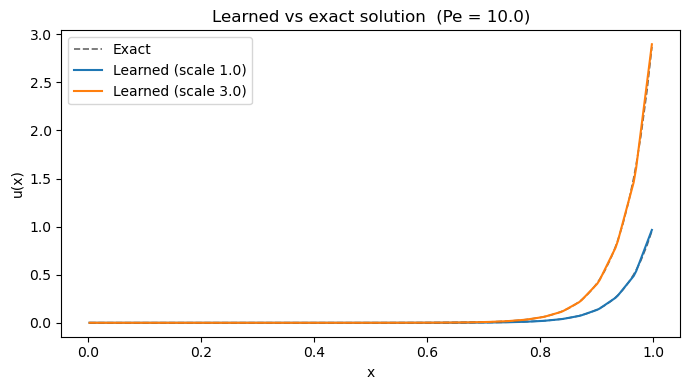

In [34]:
# Learned vs exact solution
with torch.no_grad():
    Wij = build_Wij()
    psi0_q = eval_psi0(Wij, nodal_basisEval)
    u_learned = torch.einsum('iq,di->dq', psi0_q, uhat)  # (Nbatch, Nq)

fig, ax = plt.subplots(figsize=(7, 4))
for d in range(Nbatch):
    ax.plot(xq.numpy(), udata[d].numpy(), 'k--', lw=1.2, alpha=0.6,
            label='Exact' if d == 0 else None)
    ax.plot(xq.numpy(), u_learned[d].numpy(), lw=1.5,
            label=f'Learned (scale {uscale[d]:.1f})' if d < 3 else None)
ax.set_xlabel('x');  ax.set_ylabel('u(x)')
ax.set_title(f'Learned vs exact solution  (Pe = {Pe_target})')
ax.legend();  plt.tight_layout();  plt.show()

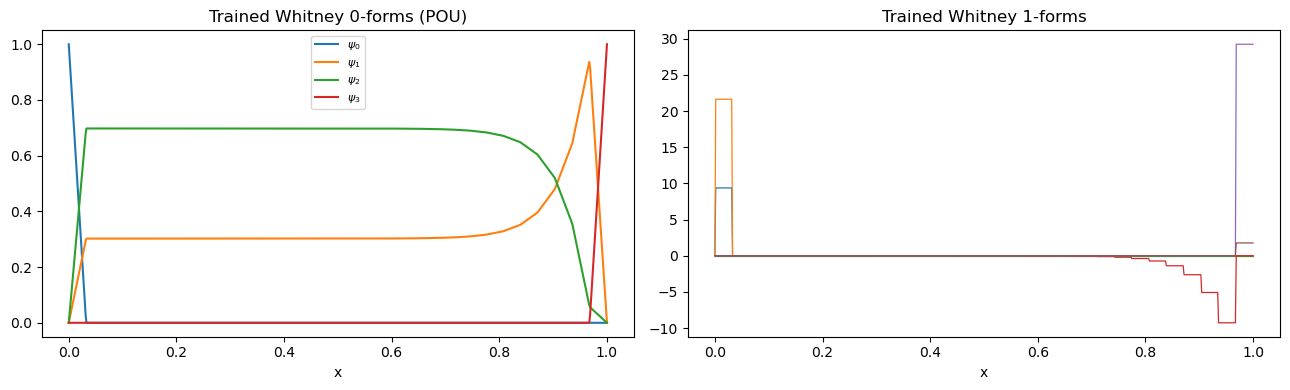

In [35]:
# Learned POU basis functions after training
with torch.no_grad():
    Wij = build_Wij()
    psi0_fine = eval_psi0(Wij, evalPhi_i(finepoints))
    psi1_fine = eval_psi1(Wij, evalPhi_i(finepoints), evalGradPhi_i(finepoints))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for i in range(Npou):
    axes[0].plot(finepoints.numpy(), psi0_fine[i].numpy(), label=rf'$\psi_{{{i}}}$')
axes[0].set_title('Trained Whitney 0-forms (POU)');  axes[0].legend(fontsize=8)

for e in range(N1forms):
    axes[1].plot(finepoints.numpy(), psi1_fine[e].numpy(), lw=0.9)
axes[1].set_title('Trained Whitney 1-forms')
for ax in axes:
    ax.set_xlabel('x')
plt.tight_layout();  plt.show()

In [36]:
# Summary: learned parameters
mu_learned = torch.exp(log_mu).item()
print(f'Learned diffusivity  mu = {mu_learned:.6f}')
print(f'True diffusivity    eps = {eps_true:.6f}')
print(f'(Note: mu need not match eps — the split between mu and N(u) is ill-posed)')

# Check magnitude of the nonlinear correction N(u)
with torch.no_grad():
    N_u_mag = flux_nn(uhat).abs().mean().item()
print(f'Mean |N(u)|:             {N_u_mag:.4e}')

Learned diffusivity  mu = 0.456862
True diffusivity    eps = 0.050000
Relative error:          813.72%
Mean |N(u)|:             2.5947e+00  (learns advection — should be nonzero)


## Step 14 — Interpretation and Exercises

### What Did the Model Learn?

| Quantity | Role | Notes |
|----------|------|-------|
| $\mu$ (diffusivity) | Scales the Hodge Laplacian $S = \delta_0^T M^1 \delta_0$ | Not guaranteed to match $\varepsilon$ — see below |
| $N(\hat{u})$ (NN correction) | Learns flux contributions beyond the linear gradient | Expected to be nonzero |
| $W$ (POU) | Clusters fine nodes into coarse groups | Adapts to concentrate resolution near features |

### Why $\mu \neq \varepsilon$ in General

The decomposition $\hat{F} = \mu\,\delta_0\,\hat{u} + N(\hat{u})$ is **ill-posed**: any amount of diffusion can be absorbed into the NN, and the NN can also push gradient-like flux onto $\mu$.  The optimiser finds *a* decomposition that fits the data, not *the* physically meaningful one.  This is a fundamental property of the model architecture, not a training failure.

The trainable $W$ adapts the POU to concentrate resolution where the solution varies most rapidly — typically near the outflow boundary layer for large Péclet numbers.

### Exercises

1. **Vary Pe**: Change `Pe_target` to 1, 50, 100.  How does the boundary layer affect learning?  Does $W$ adapt its support?
2. **Add noise**: Perturb `udata` with Gaussian noise.  How does the learned $\mu$ and $N(\hat{u})$ change?
3. **Nonlinear flux**: Replace the advection–diffusion data with Burgers-type data ($F = u^2/2 - \varepsilon u'$).  Does $N(\hat{u})$ learn the quadratic nonlinearity?
4. **Coarsening ratio**: Try `Npou = 3, 6, 8`.  What is the minimum number of POU functions that still captures the physics?
